In [1]:
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [2]:
# ── Global style ──────────────────────────
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
    "legend.frameon": False,      
    "axes.grid": False,           
    "lines.linewidth": 1.8,
    "lines.markersize": 6.5,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

In [3]:
# ── USER CONFIGURATION ────────────────────────────────────────────────────────

BETAS = ["0.00", "0.05", "0.10"]          # three β values per folder

# Appearance
L_COLORS  = {"L_12": "tab:green", "L_15": "tab:blue", "L_17": "tab:purple"}
BETA_MARKERS = {"0.00": "o", "0.05": "s", "0.10": "^"}  # circle / square / triangle

# One entry per panel (a), (b), (c) — panel_title is shown as the in-axes
# legend title.
CONFIGS = [
    dict(
        name="equal_tripartition",
        panel_title=r"$V_A \approx V_B \approx V_C$",
        legend_loc="lower left",
        FOLDER_PARAMS={
            "L_12": dict(NA=4, NB=4, range_val=500.00, deltaE=0.70),
            "L_15": dict(NA=5, NB=5, range_val=500.00, deltaE=0.70),
            "L_17": dict(NA=6, NB=6, range_val=500.00, deltaE=0.70),
        },
    ),
    dict(
        name="large_NB",
        panel_title=r"$V_B > V_C$",
        legend_loc="upper left",
        FOLDER_PARAMS={
            "L_12": dict(NA=3, NB=6, range_val=500.00, deltaE=0.70),
            "L_15": dict(NA=4, NB=7, range_val=500.00, deltaE=0.70),
            "L_17": dict(NA=4, NB=8, range_val=500.00, deltaE=0.70),
        },
    ),
    dict(
        name="large_NC",
        panel_title=r"$V_B < V_C$",
        legend_loc="lower left",
        FOLDER_PARAMS={
            "L_12": dict(NA=2, NB=3, range_val=500.00, deltaE=0.70),
            "L_15": dict(NA=3, NB=4, range_val=500.00, deltaE=0.70),
            "L_17": dict(NA=4, NB=5, range_val=500.00, deltaE=0.70),
        },
    ),
]

# ── END OF CONFIGURATION ──────────────────────────────────────────────────────


In [4]:
def build_filename(NA, NB, beta_str, range_val, deltaE):
    """Reconstruct the CSV filename from its embedded parameters."""
    range_str = f"{range_val:.2f}"
    deltaE_str = f"{deltaE:.2f}"
    return (
        f"trace_norm_distance_avg_theoretical"
        f"_NA_{NA}_NB_{NB}"
        f"_beta_{beta_str}"
        f"_range_{range_str}"
        f"_deltaE_{deltaE_str}.csv"
    )

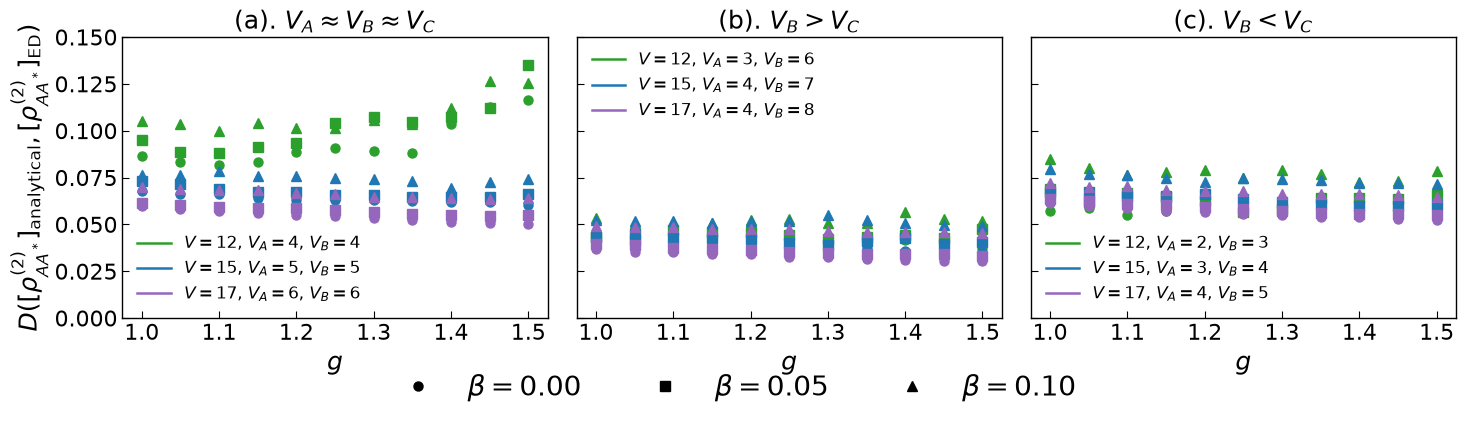

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

for ax, letter, cfg in zip(axes, "abc", CONFIGS):
    FOLDER_PARAMS = cfg["FOLDER_PARAMS"]
    L_LABELS = {
        folder: (
            rf"$V = {folder.split('_')[1]}$, "
            rf"$V_A = {params['NA']}$, "
            rf"$V_B = {params['NB']}$"
        )
        for folder, params in FOLDER_PARAMS.items()
    }

    for folder, params in FOLDER_PARAMS.items():
        color = L_COLORS[folder]

        for beta_str in BETAS:
            marker = BETA_MARKERS[beta_str]
            fname = build_filename(
                params["NA"], params["NB"],
                beta_str,
                params["range_val"], params["deltaE"],
            )
            fpath = os.path.join(folder, fname)

            if not os.path.exists(fpath):
                print(f"[WARNING] File not found, skipping:\n  {fpath}")
                continue

            df = pd.read_csv(fpath)

            # Column indices (0-based): col 0 → g,  col 2 → normalized trace norm distance
            g = df.iloc[:, 0]
            y = df.iloc[:, 2]

            ax.plot(
                g, y,
                color=color,
                marker=marker,
                markersize=6.5,
                linewidth=1.8,
                linestyle="none",
                label="_nolegend_",
            )

    # ── Per-panel legend: one entry per L value (regime shown in title) ──
    legend_handles = [
        mlines.Line2D(
            [], [],
            color=L_COLORS[folder],
            linewidth=1.8,
            label=L_LABELS[folder],
        )
        for folder in FOLDER_PARAMS
    ]
    ax.legend(handles=legend_handles, loc=cfg["legend_loc"])

    ax.set_xlabel(r"$g$")
    ax.set_title(f"({letter}). {cfg['panel_title']}", loc="center")

axes[0].set_ylabel(
    r"$D([\rho_{AA^*}^{(2)}]_{\text{analytical}}, [\rho_{AA^*}^{(2)}]_{\text{ED}})$"
)
axes[0].set_ylim(0, 0.15)

# ── Shared legend for β markers, below all three panels ────────────────────────
beta_handles = [
    mlines.Line2D(
        [], [],
        color="black",
        marker=BETA_MARKERS[beta_str],
        linestyle="none",
        markersize=6.5,
        label=fr"$\beta = {beta_str}$",
    )
    for beta_str in BETAS
]
fig.legend(
    handles=beta_handles,
    loc="lower center",
    ncol=len(BETAS),
    bbox_to_anchor=(0.5, -0.06),
    frameon=False,
    fontsize=20,
)

fig.tight_layout()
plt.savefig("fig_8.pdf", dpi=150, bbox_inches="tight")
plt.show()
